# Task 3-5 (Extra): CNN Autoencoder vs Dense Deep Autoencoder


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [33]:
transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_ds = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [ ]:
class DenseDeepAE(nn.Module):
    def __init__(self, input_size=784, encoding_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, encoding_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, input_size), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# CNN Autoencoder: Conv down to latent, ConvTranspose up (must get 28x28 at the end)
class CNNAutoEncoder(nn.Module):
    def __init__(self, encoding_channels=8):
        super().__init__()
        # Encoder: 1x28x28 -> 16x14x14 -> 32x7x7 -> encoding_channels x 3x3 (last conv padding=0 so 7->3)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(), nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, encoding_channels, 3, stride=2, padding=0), nn.ReLU(),
        )
        # Decoder: 3x3 -> 7x7 -> 14x14 -> 28x28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(encoding_channels, 32, 3, stride=2, padding=1, output_padding=2), nn.ReLU(), nn.BatchNorm2d(32),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(), nn.BatchNorm2d(16),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
def train_ae(model, train_loader, test_loader, epochs=5, lr=1e-3, dense=True, name="AE"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        run = 0.0
        for images, _ in train_loader:
            if dense:
                x = images.view(-1, 784).to(device)
            else:
                x = images.to(device)
            optimizer.zero_grad()
            recon = model(x)
            loss = mse(recon, x)
            loss.backward()
            optimizer.step()
            run += loss.item()
        epoch_train = run / len(train_loader)
        train_losses.append(epoch_train)

        model.eval()
        te = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                if dense:
                    x = images.view(-1, 784).to(device)
                else:
                    x = images.to(device)
                recon = model(x)
                te += mse(recon, x).item()
        epoch_test = te / len(test_loader)
        test_losses.append(epoch_test)
        print(f"{name} - epoch {epoch+1}/{epochs}: train loss={epoch_train:.5f}, test loss={epoch_test:.5f}")
    return train_losses, test_losses

In [36]:
EPOCHS = 20

torch.manual_seed(42)
dense_ae = DenseDeepAE(encoding_dim=32)
dense_tr, dense_te = train_ae(dense_ae, train_loader, test_loader, epochs=EPOCHS, dense=True, name="Dense Deep AE")

torch.manual_seed(42)
cnn_ae = CNNAutoEncoder(encoding_channels=8)
cnn_tr, cnn_te = train_ae(cnn_ae, train_loader, test_loader, epochs=EPOCHS, dense=False, name="CNN AE")

best_epoch_dense = min(range(len(dense_te)), key=lambda i: dense_te[i])
best_epoch_cnn = min(range(len(cnn_te)), key=lambda i: cnn_te[i])
comparison = pd.DataFrame({
    "Model": ["Dense Deep AE", "CNN AE"],
    "Final train loss": [dense_tr[-1], cnn_tr[-1]],
    "Final test loss": [dense_te[-1], cnn_te[-1]],
    "Min test loss": [min(dense_te), min(cnn_te)],
    "Best epoch": [best_epoch_dense, best_epoch_cnn],
})
print(f"Dense Deep AE: best test loss {min(dense_te):.5f} at epoch {best_epoch_dense}")
print(f"CNN AE: best test loss {min(cnn_te):.5f} at epoch {best_epoch_cnn}")
comparison

Dense Deep AE - epoch 1/20: train loss=0.03047, test loss=0.02011
Dense Deep AE - epoch 2/20: train loss=0.01822, test loss=0.01673
Dense Deep AE - epoch 3/20: train loss=0.01566, test loss=0.01492
Dense Deep AE - epoch 4/20: train loss=0.01420, test loss=0.01376
Dense Deep AE - epoch 5/20: train loss=0.01312, test loss=0.01282
Dense Deep AE - epoch 6/20: train loss=0.01237, test loss=0.01228
Dense Deep AE - epoch 7/20: train loss=0.01175, test loss=0.01169
Dense Deep AE - epoch 8/20: train loss=0.01128, test loss=0.01129
Dense Deep AE - epoch 9/20: train loss=0.01088, test loss=0.01086
Dense Deep AE - epoch 10/20: train loss=0.01053, test loss=0.01066
Dense Deep AE - epoch 11/20: train loss=0.01024, test loss=0.01032
Dense Deep AE - epoch 12/20: train loss=0.00999, test loss=0.01010
Dense Deep AE - epoch 13/20: train loss=0.00978, test loss=0.01004
Dense Deep AE - epoch 14/20: train loss=0.00960, test loss=0.00981
Dense Deep AE - epoch 15/20: train loss=0.00943, test loss=0.00963
Dens

,Model,Final train loss,Final test loss,Min test loss,Best epoch
0,Dense Deep AE,0.008879,0.009209,0.009209,19
1,CNN AE,0.026619,0.026661,0.026654,18


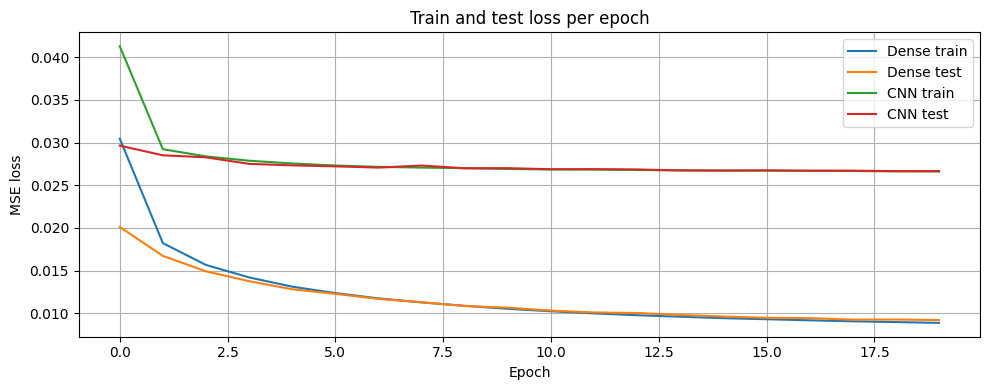

In [37]:
# Loss curves: train vs test for both models
plt.figure(figsize=(10, 4))
epochs = range(EPOCHS)
plt.plot(epochs, dense_tr, label="Dense train")
plt.plot(epochs, dense_te, label="Dense test")
plt.plot(epochs, cnn_tr, label="CNN train")
plt.plot(epochs, cnn_te, label="CNN test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Train and test loss per epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

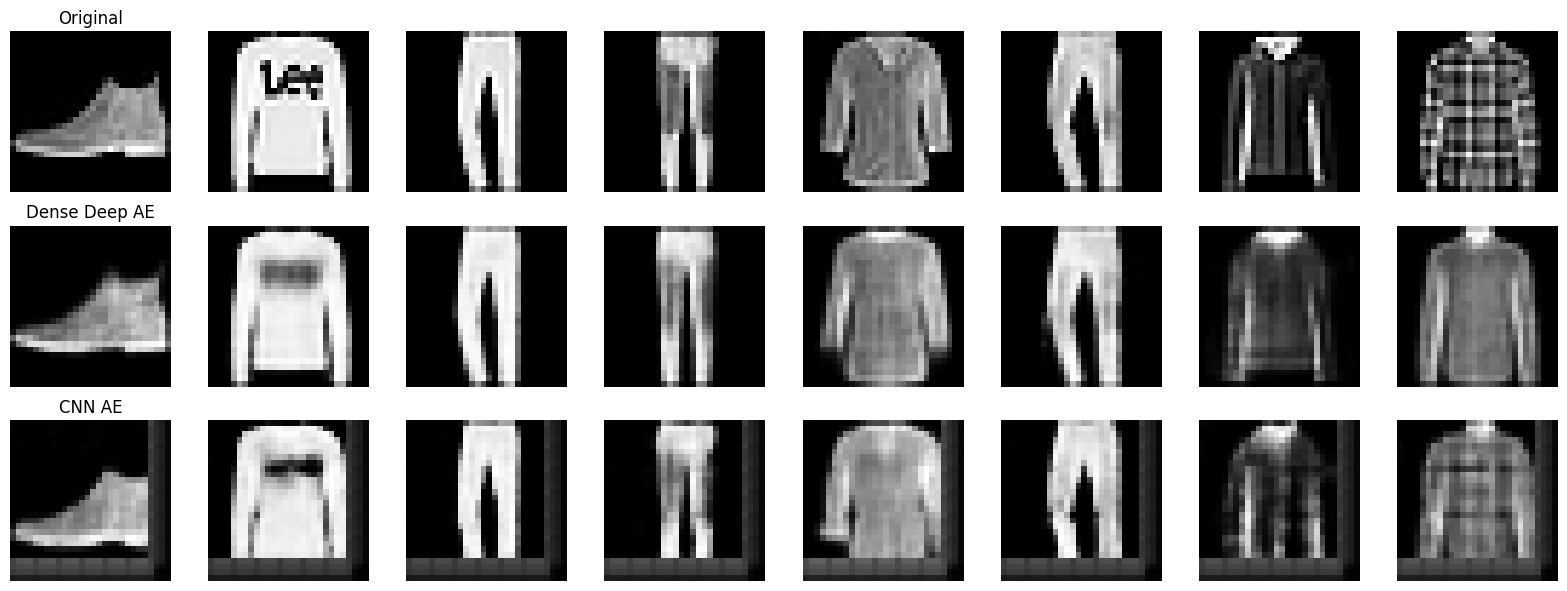

In [38]:
# Visual comparison: original, Dense Deep recon, CNN recon
dense_ae.eval()
cnn_ae.eval()
images, _ = next(iter(test_loader))
n = 8

x_flat = images.view(-1, 784).to(device)
x_img = images.to(device)
with torch.no_grad():
    recon_dense = dense_ae(x_flat).cpu().view(-1, 1, 28, 28)
    recon_cnn = cnn_ae(x_img).cpu()

images = images.cpu()
fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
for i in range(n):
    axes[0, i].imshow(images[i, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_dense[i, 0], cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(recon_cnn[i, 0], cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("Original")
axes[1, 0].set_title("Dense Deep AE")
axes[2, 0].set_title("CNN AE")
plt.tight_layout()
plt.show()